# Skill Check
## Capstone 2 
### Sharleen Guerrero | 05-24-2026

---

This guide is a concise reference for the Python and data analysis skills needed in the 
Capstone 2 Project. Core skills include the foundation of Pandas lobrary, analysis functions, visualization in Matplotlib, jupyter notebook best practices, and Git version control.

# Section 1: Foundational Skills

## 1.1 Loading and Inspecting Data with Pandas

In [26]:
# pd.read_csv() - A Pandas library function that converts csv files into DataFrames
# df.info() Gives column names, data types, and non-null values

# Import the library
import pandas as pd

# Convert Csv files to DataFrames
# All files in the same folder
# Syntax dataframe_name = pd.read_csv("Name of file/File Path")

# customer_list.csv
customer_list = pd.read_csv("customer_list.csv", sep='|')
# customer_list.csv uses pipe symbols | as delimiters
# instead of the standard comma separator
# sep='|' tells pandas to split columns on | instead of ,
# without this, all data loads as one single column
# You can identify this need by checking the raw CSV file
# or by noticing all data appears in one column after loading
customer_list.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


In [15]:
# ProductCategories.csv
product_categories = pd.read_csv("ProductCategories.csv")
product_categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [16]:
# Products.csv
products = pd.read_csv("Products.csv")
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [17]:
# StoreDetail.csv
store_details = pd.read_csv("StoreDetail.csv")
store_details.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [37]:
# StoreSales.csv
store_sales = pd.read_csv("StoreSales.csv")
store_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


## Data Inspection Notes

- Transaction Date in StoreSales (and possibly customer_list) must be converted 
  to datetime using pd.to_datetime() before analysis
- RewardsID is float because NaN values exist —
  indicates non-rewards customers
- Prod Num and SubcategoryID are intentionally strings —
  used as labels and join keys, not for calculation
  Also, might include letters in a product code.
- No null values found across any DataFrame

In [29]:
# Familiarzing myself with each DataFrame
# df.head() previews first 5 rows as default
# df.shape() returns a tuple with dimensions of DataFrame (rows x columns)
# helps avoid printing entire DataFrames

print(customer_list.head())
print()
print(customer_list.shape)

   cust_id        date      time           name  \
0        1  2023-03-15  08:45:12         Rachel   
1        2  2023-05-22  12:30:45      R. Geller   
2        3  2023-07-09  18:15:27  Monica Geller   
3        4  2023-09-01  21:05:33  Chandler Bing   
4        5  2023-11-18  14:22:10           Joey   

                            email         phone sms-opt-out   
0       rachel@centralperk.coffee  212-555-1001            N  
1        rossg@centralperk.coffee  212-555-1002            N  
2   chefmonica@centralperk.coffee  212-555-1003            N  
3    chandlerb@centralperk.coffee  212-555-1004            Y  
4  howyoudoing@centralperk.coffee  212-555-1005            N  

(521, 7)


In [30]:
print(product_categories.head())
print()
print(product_categories.shape)

   CategoryID                  Category SubcategoryID           Subcategory
0         120  Technology & Accessories       120-tab               Tablets
1         120  Technology & Accessories       120-cal           Calculators
2         120  Technology & Accessories       120-sof     Software Download
3         120  Technology & Accessories       120-hea            Headphones
4         120  Technology & Accessories       120-ext  External Accessories

(52, 4)


In [32]:
print(products.head())
print()
print(products.shape)

    Prod Num                        Product  CategoryID SubcategoryID
0  105248-IT               TCL NXTPAPER 10s         120       120-tab
1  105249-IT  Dell Latitude 7320 Detachable         120       120-tab
2  105250-IT                     Realme Pad         120       120-tab
3  105251-IT             Lenovo Tab P12 Pro         120       120-tab
4  105252-IT        Microsoft Surface Pro 9         120       120-tab

(669, 4)


In [33]:
print(store_details.head())
print()
print(store_details.shape)

  Store Location     State  Store ID Territory Manager Region  Region Director
0         Aurora  Colorado       701          Jim Heck   West  Cassie Chambers
1       Berthoud  Colorado       702          Jim Heck   West  Cassie Chambers
2        Boulder  Colorado       703          Jim Heck   West  Cassie Chambers
3    Castle Rock  Colorado       704          Jim Heck   West  Cassie Chambers
4         Denver  Colorado       705          Jim Heck   West  Cassie Chambers

(111, 6)


In [34]:
print(store_sales.head())
print()
print(store_sales.shape)

  Transaction Date  Store ID  RewardsID  Prod Num  Sale Amount
0         1/1/2022       702        NaN  105349-M         8.00
1         1/1/2022       704        NaN  105350-T       144.00
2         1/1/2022       705        NaN  105351-M        44.00
3         1/1/2022       705        NaN  105352-M        47.61
4         1/1/2022       705        NaN  105353-A        20.36

(335129, 5)


## Data Inspection Notes Continued

- StoreSales is the largest DataFrame at 335,129 
  rows × 5 columns — primary analysis table
  
- RewardsID contains NaN values in StoreSales —
  indicates non-rewards customers exist
  **IMPORTANT**: Use LEFT JOIN not INNER JOIN for Q4
  to preserve all transactions including non-members

- Transaction Date in StoreSales must be converted 
  to datetime using pd.to_datetime() before analysis

- RewardsID is float because NaN values exist —
  pandas automatically converts int columns 
  with NaN to float

- SubcategoryID and Prod Num are intentionally 
  strings — confirmed they contain letters
  ex. "10525-A", "1A" — used as labels 
  and join keys only, not for calculation

- customer_list sms-opt-out column uses Y/N 
  Y = opted out, N = not opted out
  Marketing opportunity: target N customers
  for SMS campaigns

- No null values found in any other DataFrame

- customer_list uses pipe | delimiter instead 
  of standard comma — requires sep='|' parameter

## 1.2 Filtering DataFrames

In [41]:
# .isnin()
# Filters rows where a column value matches any item in a list
# Can be used for multiple conditions
# df[df['col'].isin([val1, val2])]

# Who are the territory managers for the sales territories assigned? 
# What are the store IDs and cities for the stores in each assigned sales territory

# Filter to your two territories
assigned_territories = store_details[store_details['State'].isin(['Texas', 'New Jersey'])]

# Display relevant columns only
assigned_territories[['Store ID', 'Store Location', 'State', 'Territory Manager']]

,Store ID,Store Location,State,Territory Manager
70,824,Atlantic City,New Jersey,Miami Vue
71,825,Bayonne,New Jersey,Miami Vue
72,826,Cape May,New Jersey,Miami Vue
73,827,Clifton,New Jersey,Miami Vue
74,828,East Orange,New Jersey,Miami Vue
75,829,Hackensack,New Jersey,Miami Vue
76,830,Hoboken,New Jersey,Miami Vue
77,831,Jersey City,New Jersey,Miami Vue
78,832,Montclair,New Jersey,Miami Vue
79,833,Morristown,New Jersey,Miami Vue


In [42]:
# Counting total stores for New Jersey and Texas Combined
print(assigned_territories.shape)

(27, 6)


In [49]:
# Count stores per state
assigned_territories.groupby('State')['Store ID'].count()

State
New Jersey    16
Texas         11
Name: Store ID, dtype: int64

In [58]:
# How many unique Store IDs are in StoreSales?
print(store_sales['Store ID'].nunique())

# How many unique Store IDs are in StoreDetail?
print(store_detail['Store ID'].nunique())

111
111


**Note on In-Store Sales:**
StoreSales contains 111 unique Store IDs,
matching exactly the 111 physical stores 
in StoreDetail. No online sales exist in 
this dataset — all transactions are in-store.
No additional filtering required.

In [55]:
# Boolean indexing
# Selecting rows that match a condition
# df[df['column'] == value]
# Conditions use & (and) or | (or)

# Show only Texas stores
texas_stores = assigned_territories[assigned_territories['State'] == 'Texas']
texas_stores[['Store ID', 'Store Location', 'Territory Manager']]

,Store ID,Store Location,Territory Manager
100,901,Arlington,"Jeff ""Howdy"" Richards"
101,902,Austin,"Jeff ""Howdy"" Richards"
102,903,Bacliff,"Jeff ""Howdy"" Richards"
103,904,Baytown,"Jeff ""Howdy"" Richards"
104,905,Beaumont,"Jeff ""Howdy"" Richards"
105,906,Cedar Park,"Jeff ""Howdy"" Richards"
106,907,Dallas,"Jeff ""Howdy"" Richards"
107,908,Denton,"Jeff ""Howdy"" Richards"
108,909,Desoto,"Jeff ""Howdy"" Richards"
109,910,Fort Worth,"Jeff ""Howdy"" Richards"


In [53]:
# Show only New Jersey stores
nj_stores = assigned_territories[assigned_territories['State'] == 'New Jersey']
nj_stores[['Store ID', 'Store Location', 'Territory Manager']]

,Store ID,Store Location,Territory Manager
70,824,Atlantic City,Miami Vue
71,825,Bayonne,Miami Vue
72,826,Cape May,Miami Vue
73,827,Clifton,Miami Vue
74,828,East Orange,Miami Vue
75,829,Hackensack,Miami Vue
76,830,Hoboken,Miami Vue
77,831,Jersey City,Miami Vue
78,832,Montclair,Miami Vue
79,833,Morristown,Miami Vue


In [59]:
# Filter StoreSales to only show transactions greater than $500
# Using a boolean mask — True/False array where Sale Amount > 500
# Wrapping mask in store_sales to retrieve actual matching rows
high_transactions = store_sales[store_sales['Sale Amount'] > 500]
high_transactions.head(10)

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
37,1/1/2022,736,NaN,105326-IT,1717.70
88,1/1/2022,813,NaN,105250-IT,837.28
101,1/1/2022,824,NaN,105337-IT,1301.88
131,1/1/2022,867,NaN,105330-IT,1376.44
138,1/1/2022,904,NaN,105326-IT,1717.70
139,1/1/2022,906,NaN,105347-IT,837.52
143,1/1/2022,908,328.0,105337-IT,1301.88
163,1/2/2022,718,NaN,105331-IT,1294.30
176,1/2/2022,727,NaN,105458-IT,637.52
185,1/2/2022,736,NaN,105262-IT,603.50


## Q1 Findings: Territory Managers & Store Locations

**Texas Territory**
- Territory Manager: Jeff "Howdy" Richards
- Number of Stores: 11
- Store IDs: 901-911

**New Jersey Territory**
- Territory Manager: Miami Vue
- Number of Stores: 16
- Store IDs: 824-839

**Note:** New Jersey has 45% more store locations
than Texas — important context for revenue comparison

## 1.3 Merging DataFrames

In [65]:
# Scenario 1: Every transaction in StoreSales needs city and state info added to it
# Left join merge needed becasuse I want to keep all rows from StoreSales, then add city 
# and state columns from StoreDetails.
# Then I can filter by my states
full_store = store_sales.merge(store_details, on='Store ID', how='left')
print(full_store.head(5))

  Transaction Date  Store ID  RewardsID  Prod Num  Sale Amount Store Location  \
0         1/1/2022       702        NaN  105349-M         8.00       Berthoud   
1         1/1/2022       704        NaN  105350-T       144.00    Castle Rock   
2         1/1/2022       705        NaN  105351-M        44.00         Denver   
3         1/1/2022       705        NaN  105352-M        47.61         Denver   
4         1/1/2022       705        NaN  105353-A        20.36         Denver   

      State Territory Manager Region  Region Director  
0  Colorado          Jim Heck   West  Cassie Chambers  
1  Colorado          Jim Heck   West  Cassie Chambers  
2  Colorado          Jim Heck   West  Cassie Chambers  
3  Colorado          Jim Heck   West  Cassie Chambers  
4  Colorado          Jim Heck   West  Cassie Chambers  


In [66]:
# Scenario 2: You only want transactions that have a matching store in StoreDetail
# Inner join needed here because I want a match from both tables
store_transactions = store_sales.merge(store_details, on='Store ID', how='inner')
print(store_transactions.head(5))

  Transaction Date  Store ID  RewardsID  Prod Num  Sale Amount Store Location  \
0         1/1/2022       702        NaN  105349-M         8.00       Berthoud   
1         1/1/2022       704        NaN  105350-T       144.00    Castle Rock   
2         1/1/2022       705        NaN  105351-M        44.00         Denver   
3         1/1/2022       705        NaN  105352-M        47.61         Denver   
4         1/1/2022       705        NaN  105353-A        20.36         Denver   

      State Territory Manager Region  Region Director  
0  Colorado          Jim Heck   West  Cassie Chambers  
1  Colorado          Jim Heck   West  Cassie Chambers  
2  Colorado          Jim Heck   West  Cassie Chambers  
3  Colorado          Jim Heck   West  Cassie Chambers  
4  Colorado          Jim Heck   West  Cassie Chambers  


In [67]:
print(store_sales.columns.tolist())
print(full_store.columns.tolist())

['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount']
['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount', 'Store Location', 'State', 'Territory Manager', 'Region', 'Region Director']


In [85]:
# Merging full_store with Products on shared Prod Num key
full_data = store_sales.merge(store_detail, on='Store ID', how='left') \
                       .merge(products, on='Prod Num', how='left')
print(full_data.shape)
print(full_data.columns.tolist())

(335129, 13)
['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount', 'Store Location', 'State', 'Territory Manager', 'Region', 'Region Director', 'Product', 'CategoryID', 'SubcategoryID']


**MERGE LESSON LEARNED**:
Don't create one giant merged DataFrame!
Merge only the tables needed per question
Merging too many tables can cause row inflation
Always check shape before and after every merge
335,129 rows = correct, anything more = problem

In [86]:
# Check for duplicate rows
print(store_sales.duplicated().sum())

# Check for negative or zero sale amounts
print(store_sales[store_sales['Sale Amount'] <= 0].shape)

# Check Transaction Date format consistency
store_sales['Transaction Date'].head(20)

0
(0, 5)


0     1/1/2022
1     1/1/2022
2     1/1/2022
3     1/1/2022
4     1/1/2022
5     1/1/2022
6     1/1/2022
7     1/1/2022
8     1/1/2022
9     1/1/2022
10    1/1/2022
11    1/1/2022
12    1/1/2022
13    1/1/2022
14    1/1/2022
15    1/1/2022
16    1/1/2022
17    1/1/2022
18    1/1/2022
19    1/1/2022
Name: Transaction Date, dtype: str

## Data Quality Check Results
- 0 duplicate rows
- 0 negative or zero sale amounts  
- Transaction Date format consistent — M/D/YYYY
- Transaction Date dtype = str — must convert!
- RewardsID nulls expected — non-rewards customers
- Data is clean and ready for analysis

# Section 2: Analysis Skills

## 2.1 Working with Dates & Time Periods

In [88]:
# Task 1 — convert Transaction Date to datetime

store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])
# converts to real datetime

# Task 2 — create YearMonth column
store_sales['YearMonth'] = store_sales['Transaction Date'].dt.to_period('M')
# Collapses to year-month lable 2022-01

# Verify both changes worked
store_sales[['Transaction Date', 'YearMonth']].head()

,Transaction Date,YearMonth
0,2022-01-01,2022-01
1,2022-01-01,2022-01
2,2022-01-01,2022-01
3,2022-01-01,2022-01
4,2022-01-01,2022-01


In [89]:
# What is the full date range of the data?
print(store_sales['YearMonth'].min())
print(store_sales['YearMonth'].max())

2022-01
2025-12


- Data covers January 2022 — December 2025
- 4 full years = 48 months of trend data
- Enough data to show year over year patterns
- Strong foundation for marketing recommendation

## 2.2 Grouping & Aggregating

In [96]:
# "Calculate the total monthly revenue for each individual store across all territories
sales_with_state = store_sales.merge(store_detail, 
                                      on='Store ID', 
                                      how='left')
monthly_revenue = store_sales.groupby(['YearMonth', 'Store ID'])['Sale Amount'].sum().reset_index()
print(monthly_revenue)

# groupby(['YearMonth', 'Store ID'])  returns only combinations that exist
# Zero sales months simply don't appear
# 5,328 possible - 5,260 actual = 68 months where a store had no sales
# Could be due to underperformance, recently opened, seasonal closures

     YearMonth  Store ID  Sale Amount
0      2022-01       701      4011.09
1      2022-01       702      4272.12
2      2022-01       703      4015.72
3      2022-01       704      2770.37
4      2022-01       705     10467.31
...        ...       ...          ...
5255   2025-12       906     10234.46
5256   2025-12       908     11252.43
5257   2025-12       909      4691.92
5258   2025-12       910      6173.99
5259   2025-12       911      6789.56

[5260 rows x 3 columns]


In [104]:
# Count transactions per store
transactions_per_store = store_sales.groupby('Store ID')['Sale Amount'].count().reset_index()
# Always rename after count() or sum()
# so column name reflects what it contains!
transactions_per_store = transactions_per_store.rename(columns={'Sale Amount': 'Transaction Count'})
transactions_per_store

,Store ID,Transaction Count
0,701,2292
1,702,2141
2,703,2281
3,704,2171
4,705,6591
...,...,...
106,907,430
107,908,2164
108,909,2343
109,910,2208


In [107]:
# .agg()
# df.groupby('StoreID').agg({'SaleAmount': ['sum', 'mean', 'count']}). 
# Returns a DataFrame with one column per aggregation, useful for summary tables

# Get total revenue AND transaction count per store
store_summary = store_sales.groupby('Store ID')['Sale Amount'].agg(['sum', 'count']).reset_index()
store_summary

,Store ID,sum,count
0,701,317198.67,2292
1,702,281182.34,2141
2,703,321197.88,2281
3,704,299122.02,2171
4,705,917471.53,6591
...,...,...,...
106,907,54444.05,430
107,908,298111.45,2164
108,909,330720.12,2343
109,910,351772.59,2208


## 2.3 Sorting and Ranking

In [118]:
# Using store_summary — sort stores by total revenue from highest to lowest and show top 10
# Which store is top performer in YOUR territories?
store_summary = store_summary.rename(columns={
    'sum': 'Total Revenue',
    'count': 'Transaction Count'
})

top_stores = store_summary.sort_values('Total Revenue', ascending=False)
top_stores.head(10)

,Store ID,Total Revenue,Transaction Count
35,736,8708119.00,69530
4,705,917471.53,6591
8,709,640368.11,4405
104,905,637818.90,4403
73,835,623163.53,4443
88,850,621565.02,4476
23,724,618846.25,4457
85,847,607148.21,4382
55,817,602183.44,4477
76,838,597565.68,4294


In [120]:
# Same result, one line, no sorting needed
store_summary.nlargest(10, 'Total Revenue')

,Store ID,Total Revenue,Transaction Count
35,736,8708119.00,69530
4,705,917471.53,6591
8,709,640368.11,4405
104,905,637818.90,4403
73,835,623163.53,4443
88,850,621565.02,4476
23,724,618846.25,4457
85,847,607148.21,4382
55,817,602183.44,4477
76,838,597565.68,4294


## 2.4 Pivot Tables

In [127]:
# Merge with products to get CategoryID
my_sales_products = my_sales.merge(products, on='Prod Num', how='left')

# Merge with product_categories on BOTH keys to avoid row inflation
my_sales_full = my_sales_products.merge(product_categories, 
                                         on=['CategoryID', 'SubcategoryID'], 
                                         how='left')

# Check rows didn't inflate!
print(my_sales_full.shape)

(64720, 16)


In [130]:
category_pivot = pd.pivot_table(my_sales_full,
                                 index='Category',
                                 columns='State',
                                 values='Sale Amount',
                                 aggfunc=sum).fillna(0)
category_pivot

State,New Jersey,Texas
Category,,
Apparel and Merchandise,237281.41,142403.22
Art Supplies,225414.36,139084.75
Books (General),90319.41,58436.68
Stationery and Supplies,83170.46,54322.23
Technology & Accessories,3630738.42,2445117.66
Textbooks,936799.67,596616.41


# Section 3: Visualization Skills

## 3.1 Bar Chart

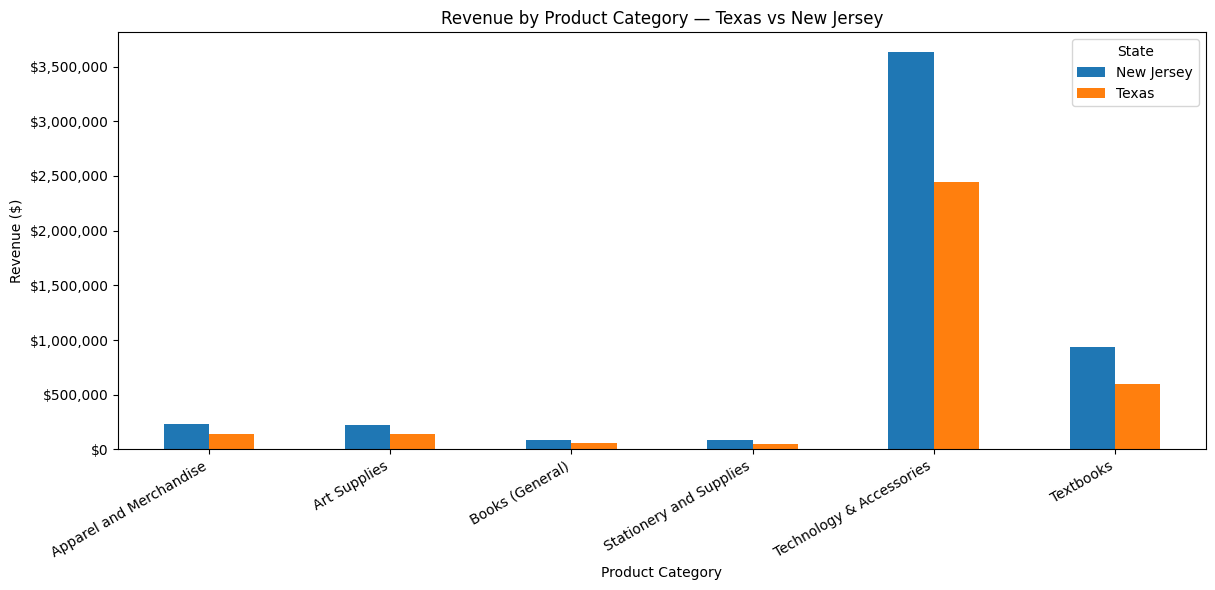

In [136]:
# Create canvas — width 12 inches, height 6 inches
plt.figure(figsize=(12, 6))

# Plot grouped bar chart directly from pivot table
# kind='bar' — vertical grouped bar chart
# ax=plt.gca() — gca means "get current axes"
# tells pandas to draw on the canvas we just created
# without this, pandas might create a separate figure
category_pivot.plot(kind='bar', ax=plt.gca())

# Add descriptive title to the chart
plt.title('Revenue by Product Category — Texas vs New Jersey')

# Label the x axis — what the bars represent
plt.xlabel('Product Category')

# Label the y axis — what the bar heights represent
plt.ylabel('Revenue ($)')

# Rotate x axis category labels 30 degrees
# ha='right' — right aligns labels after rotation
# prevents labels from overlapping each other
plt.xticks(rotation=30, ha='right')

# Add legend showing which color = which state
plt.legend(title='State')

# Automatically adjust spacing so nothing is cut off
plt.tight_layout()

# Format y axis numbers as currency
# gca() = get current axes (the active chart)
# set_major_formatter — changes how axis numbers display
# FuncFormatter — applies a custom formatting function
# lambda x, p: f'${x:,.0f}' — formats numbers like $3,600,000
# x = the number, p = position (required but unused here)
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(
        lambda x, p: f'${x:,.0f}'))

# Render and display the chart in the notebook
plt.show()

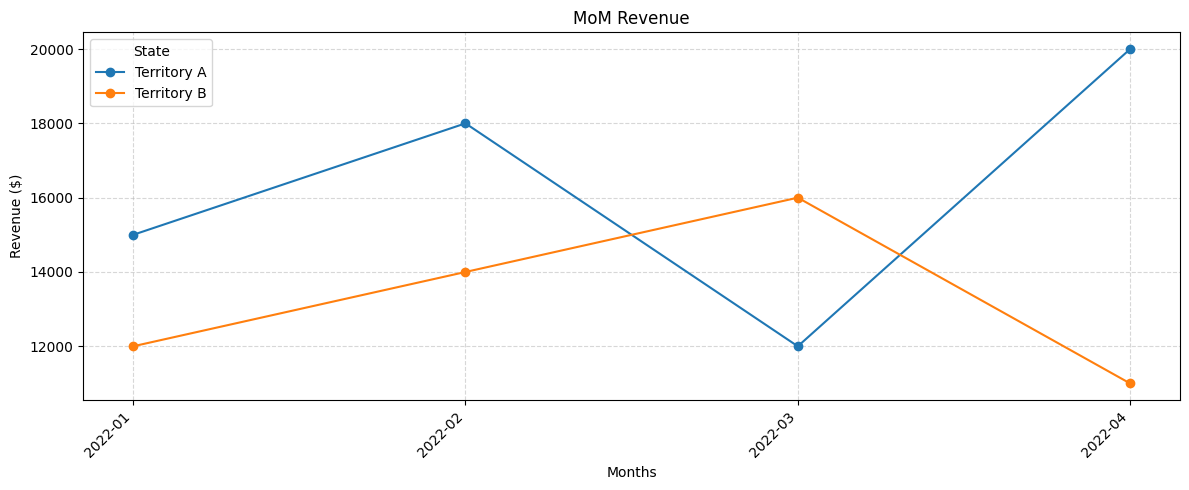

In [137]:
# Practice data — not real capstone data
months = ['2022-01', '2022-02', '2022-03', '2022-04']
revenue_a = [15000, 18000, 12000, 20000]
revenue_b = [12000, 14000, 16000, 11000]

# Create canvas — width 12 inches, height 5 inches
# wider than tall — good for trend charts with many x labels
plt.figure(figsize=(12, 5))

# Draw first line — Territory A
# months = x axis values (what goes along the bottom)
# revenue_a = y axis values (what goes up the side)
# marker='o' — adds a circle dot at each data point
# label= — name that appears in the legend
plt.plot(months, revenue_a, marker='o', label='Territory A')

# Draw second line — Territory B on SAME chart
# calling plt.plot() twice overlays both lines
plt.plot(months, revenue_b, marker='o', label='Territory B')

# Add descriptive title
plt.title('MoM Revenue')

# Label x axis — what the x values represent
plt.xlabel('Months')

# Label y axis — what the y values represent
plt.ylabel('Revenue ($)')

# Rotate x axis tick labels 45 degrees
# rotation=45 — angle of the label text
# ha='right' — ha means "horizontal alignment"
# right aligns the END of the label to the tick mark
# without ha='right' rotated labels look misaligned
# use rotation=45 for longer labels like dates
# use rotation=30 for shorter labels like categories
plt.xticks(rotation=45, ha='right')

# Add legend box showing which line = which territory
# title= — bold header inside the legend box
plt.legend(title='State')

# Add background grid to help read values off y axis
# True — turns grid on
# linestyle='--' — dashed lines instead of solid
# alpha=0.5 — 50% transparency so grid doesn't overpower data
plt.grid(True, linestyle='--', alpha=0.5)

# Automatically adjust all elements so nothing overlaps
# or gets cut off at the edges
plt.tight_layout()

# Render and display the chart in the notebook
plt.show()

## Section 4: Notebook Structure & Git Best Practices

---

### 4.1 Jupyter Notebook Best Practices

#### Markdown Cells
- Use markdown cells to **introduce every question** before the code
- Use markdown cells to **interpret every result** after the code
- Structure every question like this:
  - **Intro markdown** → what are we trying to find and why?
  - **Code cell** → the actual analysis
  - **Interpretation markdown** → what did we find? what does it mean?
- Use `##` for section headers, `###` for question headers, `**bold**` for emphasis
- Write as if presenting to a marketing manager — tell the story!

#### Code Cell Organisation
- **One logical operation per code cell** — one merge, one groupby, one chart
- Never pack multiple unrelated steps into one cell
- Always add comments above your code explaining what and why
- End code cells with the variable name (not print()) for clean DataFrame rendering
- Use `.head(10)` or `.head(20)` to cap output — never display hundreds of rows

#### Before Submitting
- **Restart Kernel → Run All** — every single cell must run without errors
- Check every chart has title, xlabel, ylabel, legend
- Check every question has intro + code + interpretation
- Check all variable names are consistent throughout

#### Naming Conventions
- Use `snake_case` for variable names: `store_sales`, `my_sales`, `monthly_revenue`
- Use descriptive names — never just `df`
- File name: `guerrero_sales_analysis.ipynb`

---

### 4.2 Git & Version Control

#### Daily Workflow — Three Commands Every Day
```bash
git add .
git commit -m "Complete Q2 monthly revenue analysis"
git push
```

#### Good vs Bad Commit Messages
| ✅ Good | ❌ Bad |
|---------|--------|
| "Complete Q1 territory manager analysis" | "update" |
| "Add monthly revenue line chart" | "fix" |
| "Add marketing recommendation with data citations" | "pushed work" |
| "Load and inspect all 5 datasets" | "wip" |

#### Commit Rules
- Commit **at least once per day** — non negotiable!
- Commit **after completing each question**
- Use **present tense imperative** style
- Message should describe **what changed** not that something changed

#### README Must Include
- Project description
- Territories analyzed: Texas vs New Jersey
- Territory managers: Jeff "Howdy" Richards + Miami Vue
- How to run the notebook
- Link to video recording

---

### Golden Rules for a Standout Capstone

> ✅ Markdown storytelling separates data dumps from data stories
> 
> ✅ Every result needs interpretation — what does it MEAN for the business?
> 
> ✅ Clean run top to bottom — non negotiable
> 
> ✅ Commit daily with meaningful messages
> 
> ✅ Done > perfect — core requirements first!
> 
> ✅ Your recommendation must cite specific numbers from your analysis